# 03 Geo experiment - Part A: design and pre-registration
**Question:** which channel and which cities should we test, and what is the smallest effect this test can detect?

*Prakriti Foods is fictional; all data is synthetic. Everything here uses stage-1 data (weeks 1-87) only. The sealed truth has not been opened.*

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, itertools, json, matplotlib.pyplot as plt
w = pd.read_csv('../data/generated/weekly_geo.csv')
pre = w[(w.week>=36)&(w.week<=87)]
R = pre.pivot(index='week', columns='geo', values='revenue_lakh'); MS = pre.pivot(index='week', columns='geo', values='spend_Meta_lakh')
geos = list(R.columns)

## 1. Channel choice (step 3.1)
Meta: largest spend line, widest MMM v1b interval among the large channels, and the Head of Growth's case rests on its dashboard ROAS (see notebook 02). YouTube is rejected for this test: a long carry-over means an 8-week pause would give a muddy read.

## 2. Geo selection (step 3.2): match on the pre-period (weeks 36-87)
For each pair of cities, treated = the two cities combined, control = the other six combined. Score = how steadily treated and control track each other (the spread of log(treated/control) around its linear trend; lower is better), plus growth correlation, share of revenue at risk and share of Meta spend paused.

In [2]:
rows = []
for a, b in itertools.combinations(geos, 2):
    T = R[[a,b]].sum(axis=1); Cn = R.drop(columns=[a,b]).sum(axis=1)
    r = np.log(T) - np.log(Cn); x = np.arange(len(r)); res = r - np.polyval(np.polyfit(x, r, 1), x)
    rows.append((a+' + '+b, res.std(), np.corrcoef(np.diff(np.log(T)), np.diff(np.log(Cn)))[0,1], T.sum()/R.sum().sum(), MS[[a,b]].sum().sum()/MS.sum().sum()))
cand = pd.DataFrame(rows, columns=['pair','tracking_error','growth_corr','revenue_share','meta_spend_share']).sort_values('tracking_error').reset_index(drop=True)
cand.head(6).round(3)

,pair,tracking_error,growth_corr,revenue_share,meta_spend_share
0,Ahmedabad + Pune,0.060,0.477,0.141,0.138
1,Delhi NCR + Mumbai,0.060,0.502,0.378,0.385
2,Ahmedabad + Bengaluru,0.063,0.526,0.216,0.222
3,Mumbai + Pune,0.065,0.471,0.263,0.258
4,Bengaluru + Pune,0.065,0.529,0.234,0.240
5,Bengaluru + Hyderabad,0.066,0.447,0.277,0.279


**Choice: Ahmedabad + Pune.** It ties for the best tracking (0.060) with Delhi NCR + Mumbai, but pausing Meta there would put 14% of revenue at risk against 38%. Pre-registered tie-break rule: best tracking, then lowest revenue at risk. Caveat: both cities are 'newer geos' where influencers are stronger, so the result may not generalise to the big metros.

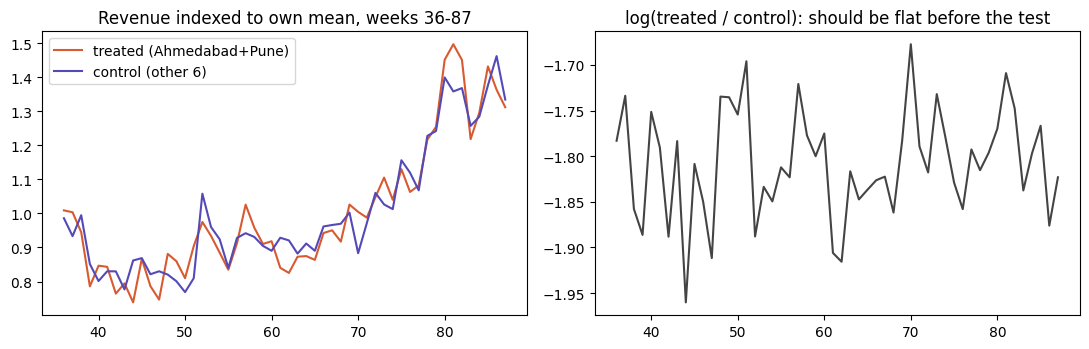

Weeks 36-87: treated geos hold 14.1% of revenue and 13.8% of Meta spend


In [3]:
A, B = 'Ahmedabad', 'Pune'; TG = [A, B]
T = R[TG].sum(axis=1); Cn = R.drop(columns=TG).sum(axis=1); r = np.log(T) - np.log(Cn)
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].plot(T/T.mean(), label='treated (Ahmedabad+Pune)', color='#D85A30'); ax[0].plot(Cn/Cn.mean(), label='control (other 6)', color='#534AB7'); ax[0].legend(); ax[0].set_title('Revenue indexed to own mean, weeks 36-87')
ax[1].plot(r, color='#444'); ax[1].set_title('log(treated / control): should be flat before the test'); plt.tight_layout(); plt.show()
print('Weeks 36-87: treated geos hold', f'{T.sum()/R.sum().sum():.1%}', 'of revenue and', f'{MS[TG].sum().sum()/MS.sum().sum():.1%}', 'of Meta spend')

## 3. Power analysis: the smallest lift we can detect (80% power, alpha 0.05)
Method: the pre-period log-ratio series is modelled as AR(1) noise. We simulate 4,000 fake experiments (52 pre weeks, 8 test weeks), inject a revenue drop of size d into the treated cities in the test weeks, and run the difference-in-differences estimate. We cross-check against the real spread of 8-week windows inside the pre-period.

AR(1) phi = 0.11, residual SD of log ratio = 0.059
Simulated null SD of the DiD estimate: 0.025 | empirical window SD: 0.023 (25 windows)
MDE (80% power, two-sided 5%): simulation 7% drop in treated-city revenue | empirical cross-check 6%


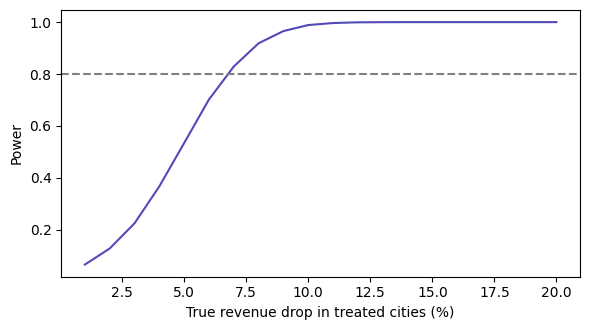

In [4]:
rs = np.random.default_rng(2026)
x = np.arange(len(r)); res = (r - np.polyval(np.polyfit(x, r, 1), x)).values
phi = np.corrcoef(res[:-1], res[1:])[0,1]; sig = res.std()
print(f'AR(1) phi = {phi:.2f}, residual SD of log ratio = {sig:.3f}')
n_sim, n_pre, n_test = 4000, 52, 8
e = rs.normal(0, sig*np.sqrt(1-phi**2), (n_sim, n_pre+n_test)); z = np.zeros_like(e); z[:,0] = rs.normal(0, sig, n_sim)
for t in range(1, n_pre+n_test): z[:,t] = phi*z[:,t-1] + e[:,t]
tau0 = z[:,n_pre:].mean(1) - z[:,:n_pre].mean(1)
crit = np.quantile(np.abs(tau0), .95)
drops = np.arange(0.01, 0.21, 0.01)
power = [np.mean(np.abs(tau0 + np.log(1-d)) > crit) for d in drops]
mde_sim = next(d for d,p in zip(drops, power) if p >= .8)
# empirical cross-check: 8-week windows inside the real pre-period, baseline = all earlier weeks (>=20)
emp = [r.iloc[s:s+8].mean() - r.iloc[:s].mean() for s in range(20, len(r)-8+1)]
mde_emp = (1.96+0.84)*np.std(emp); mde_emp_pct = 1-np.exp(-mde_emp)
print(f'Simulated null SD of the DiD estimate: {tau0.std():.3f} | empirical window SD: {np.std(emp):.3f} ({len(emp)} windows)')
print(f'MDE (80% power, two-sided 5%): simulation {mde_sim:.0%} drop in treated-city revenue | empirical cross-check {mde_emp_pct:.0%}')
plt.figure(figsize=(6,3.4)); plt.plot(drops*100, power, color='#534AB7'); plt.axhline(.8, color='grey', ls='--'); plt.xlabel('True revenue drop in treated cities (%)'); plt.ylabel('Power'); plt.tight_layout(); plt.show()

## 4. Is that detectable? What does MMM v1b expect Meta to be worth?
If Meta's true effect in the treated cities is smaller than the MDE, the test will probably return 'no effect detected'. We compare the MDE with what MMM v1b implies (its interval is wide, so this is only a plausibility check).

In [5]:
v1b = pd.read_csv('../model/mmm_v1b_roi_estimates.csv', index_col=0)
rev79 = w[w.week<=79].revenue_lakh.sum()/100
meta = v1b.loc['Meta']; spend79 = meta.spend_cr
share = lambda roi: roi*spend79/rev79
print(f"Meta's share of revenue implied by MMM v1b: mean {share(meta.ROI_mean):.0%}, 90% interval {share(meta.ROI_p5):.0%} to {share(meta.ROI_p95):.0%}")
print(f"MDE of the test: about {max(mde_sim, mde_emp_pct):.0%} (conservative). Test can only see Meta's effect if it is at least that large.")

Meta's share of revenue implied by MMM v1b: mean 10%, 90% interval 0% to 30%
MDE of the test: about 7% (conservative). Test can only see Meta's effect if it is at least that large.


## 5. Design summary (pre-registered)
| Item | Value |
|---|---|
| Channel | Meta (Facebook and Instagram) |
| Treated cities | Ahmedabad, Pune (Meta spend set to zero) |
| Control cities | the other six (Meta unchanged) |
| Test window | weeks 88-95 (8 weeks); weeks 96-104 observed as washout |
| Pre-period | weeks 36-87 |
| Primary metric | log of weekly revenue, treated vs control |
| Primary estimator | difference-in-differences |
| Secondary estimator | synthetic control (non-negative weights on the six control cities, fitted on weeks 36-87 only) |
| Inference | placebo windows in the pre-period plus the simulated AR(1) null; 90% interval |
| Calibration output | implied Meta ROI = lost revenue / Meta spend foregone, passed to MMM v2 as a lift-test prior |

In [6]:
design = {'channel':'Meta','treated_geos':TG,'control_geos':[g for g in geos if g not in TG],'weeks':[88,95],'pre_period':[36,87],
          'primary_estimator':'DiD on log revenue','secondary_estimator':'synthetic control','alpha':0.05,'mde_pct_conservative':round(100*max(mde_sim, mde_emp_pct),1)}
json.dump(design, open('../preregistration/design.json','w'), indent=2); design

{'channel': 'Meta',
 'treated_geos': ['Ahmedabad', 'Pune'],
 'control_geos': ['Bengaluru',
  'Chennai',
  'Delhi NCR',
  'Hyderabad',
  'Kolkata',
  'Mumbai'],
 'weeks': [88, 95],
 'pre_period': [36, 87],
 'primary_estimator': 'DiD on log revenue',
 'secondary_estimator': 'synthetic control',
 'alpha': 0.05,
 'mde_pct_conservative': np.float64(7.0)}

## Answer
Test Meta by pausing it in Ahmedabad and Pune for weeks 88-95. The test can detect a drop in treated-city revenue of about 7% or more (80% power, 5% two-sided); a simulation gives 7% and a check on real pre-period windows gives 6%. MMM v1b implies Meta is worth about 10% of revenue, but with a 90% interval of 0% to 30%. So the test is adequately powered if Meta is worth 10% or more, and will probably miss it if Meta is worth 5%. A null result would be informative too: it would say Meta's effect is below about 7% in these cities. Pre-registration is in `preregistration/design.md` and must be committed before stage 2 is generated.